In [1]:
import scanpy as sc
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp
import decoupler

import os
import sys
import logging
import warnings
from utils import *

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [2]:
%matplotlib inline

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

In [4]:
adata_file = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad'
adata = sc.read_h5ad(adata_file)

/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/anndata/_core/anndata.py:1792: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
adata_female = adata[adata.obs['sex'] == 'F']
adata_male = adata[adata.obs['sex'] == 'M']

In [34]:
custom_atrophy_pathway = ["UBB","UBC","FBXO32","TRIM63","MDM2","FBXO30","CAMK2B","TIE1","PSMA1","PSMA2","PSMA3","PSMA4","PSMA5","PSMA6","PSMA7","PSMB1","PSMB2","PSMB3","PSMB4","FBXO21","FBXO31","NEDD4","UBE2B","UBE2G1","UBE2J1","CTSL","CTSV","BNIP3","DEPP1","GABARAPL1","MAP1LC3","RETREG1","SQSTM1","CAPN1","CAPN2","ATF4","FOXO1","FOXO3A","HDAC9","RUNX1","AMPD3","CHRNA1","CDKN1A"]
# Convert to mouse gene format
custom_atrophy_pathway_mouse = convert_genes(custom_atrophy_pathway, 'human_to_mouse')
print(custom_atrophy_pathway_mouse)

['Ubb', 'Ubc', 'Fbxo32', 'Trim63', 'Mdm2', 'Fbxo30', 'Camk2b', 'Tie1', 'Psma1', 'Psma2', 'Psma3', 'Psma4', 'Psma5', 'Psma6', 'Psma7', 'Psmb1', 'Psmb2', 'Psmb3', 'Psmb4', 'Fbxo21', 'Fbxo31', 'Nedd4', 'Ube2b', 'Ube2g1', 'Ube2j1', 'Ctsl', 'Ctsv', 'Bnip3', 'Depp1', 'Gabarapl1', 'Map1lc3', 'Retreg1', 'Sqstm1', 'Capn1', 'Capn2', 'Atf4', 'Foxo1', 'Foxo3a', 'Hdac9', 'Runx1', 'Ampd3', 'Chrna1', 'Cdkn1a']


## Geneset (atrophy/senescence) scores

In [56]:
sensig_geneset_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SenSig_DEGs.csv'
fridman_down_orthologs_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_down_orthologs.csv'
fridman_up_orthologs_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_up_orthologs.csv'
senmayo_geneset_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt'
cell_age_orthologs_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/cellAge_orthologs.csv'
cell_age_human_file = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/cellAge/cellage3.tsv'

In [57]:
#SenSig
sensig_genes = pd.read_csv(sensig_geneset_file, skiprows=1)
sensig_up_genes = sensig_genes[sensig_genes['logFC'] > 0]['Gene'].tolist()  
sensig_down_genes = sensig_genes[sensig_genes['logFC'] < 0]['Gene'].tolist()
print(len(sensig_up_genes))
print(len(sensig_down_genes))
#Fridman gene sets
fridman_down_orthologs = pd.read_csv(fridman_down_orthologs_file, sep=',', header=0)['ortholog_name'].tolist()
fridman_up_orthologs = pd.read_csv(fridman_up_orthologs_file, sep=',', header=0)['ortholog_name'].tolist()
display(fridman_down_orthologs[0:5])
display(fridman_up_orthologs[0:5])
#SenMayo
senmayo_genes = pd.read_csv(senmayo_geneset_file, sep='\t', header=None)
senmayo_up_genes = senmayo_genes.iloc[0, 2:].dropna().tolist()
display(senmayo_up_genes[0:5])
cellage_orthologs = pd.read_csv(cell_age_orthologs_file, sep=',', header=0)
cellage_human = pd.read_csv(cell_age_human_file, sep='\t', header=0)

# Merge based on initial_alias (from orthologs) matching Gene symbol (from cellage)
merged = pd.merge(
    cellage_orthologs[['ortholog_name', 'initial_alias']], # Keep only these columns
    cellage_human[['Gene symbol', 'Senescence Effect']],
    left_on='initial_alias',
    right_on='Gene symbol',
    how='left'
)

# Clean up the merged dataframe
merged = merged.drop('Gene symbol', axis=1)  # Remove the redundant column
cellage_ortholog_genes = merged.rename(columns={'initial_alias': 'human_gene'})
# get the cellage_up_genes as ortholog_name
cellage_up_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Induces']['ortholog_name'].tolist()
display(cellage_up_genes[0:5])
# get the cellage_down_genes as ortholog_name 
cellage_down_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Inhibits']['ortholog_name'].tolist()
display(cellage_down_genes[0:5])


8567
9069


['Aldh1a7', 'Aldh1a1', 'Bmi1', 'Ccn4', 'Ccnb1']

['Aldh1a3', 'Aopep', 'Ccn2', 'Ccnd1', 'Cd44']

['Acvr1b', 'Ang', 'Angpt1', 'Angptl4', 'Areg']

['Aak1', 'Abcb1b', 'Abcb1a', 'Abi3', 'Abi3bp']

['Abcc6', 'Acer2', 'Acer2', 'Acer2', 'Acer2']

## Geneset scores and pathway dotplots

In [16]:
# load geneset of interest
geneset_gmt = ["/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/GOBP_FATTY_ACID_BETA_OXIDATION.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_CITRATE_CYCLE_TCA_CYCLE.v2024.1.Hs.gmt", "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_GLYCOLYSIS_GLUCONEOGENESIS.v2024.1.Hs.gmt",
               "/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/KEGG_OXIDATIVE_PHOSPHORYLATION.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM.v2024.1.Hs.gmt","/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/metabolism/REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM.v2024.1.Hs.gmt"]

geneset_df = gmt_to_decoupler_multiple_pathways(geneset_gmt, geneset_name='source', genesymbol_name='target')
geneset_df['target'] = convert_genes(geneset_df['target'].tolist(), 'human_to_mouse')
# add atrophy pathway
geneset_df = pd.concat([geneset_df, pd.DataFrame({'source': "Atrophy Pathway (PMID: 31325479)", 'target': custom_atrophy_pathway_mouse})])
# get the number of rows in each unique geneset
geneset_size = geneset_df['source'].value_counts()
display(geneset_size)
display(geneset_df)


source
KEGG_OXIDATIVE_PHOSPHORYLATION                   132
GOBP_FATTY_ACID_BETA_OXIDATION                    75
KEGG_GLYCOLYSIS_GLUCONEOGENESIS                   62
Atrophy Pathway (PMID: 31325479)                  43
KEGG_CITRATE_CYCLE_TCA_CYCLE                      31
REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM     21
REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM       14
Name: count, dtype: int64

,source,target
0,GOBP_FATTY_ACID_BETA_OXIDATION,Abcb11
1,GOBP_FATTY_ACID_BETA_OXIDATION,Abcd1
2,GOBP_FATTY_ACID_BETA_OXIDATION,Abcd2
3,GOBP_FATTY_ACID_BETA_OXIDATION,Abcd3
4,GOBP_FATTY_ACID_BETA_OXIDATION,Abcd4
...,...,...
38,Atrophy Pathway (PMID: 31325479),Hdac9
39,Atrophy Pathway (PMID: 31325479),Runx1
40,Atrophy Pathway (PMID: 31325479),Ampd3
41,Atrophy Pathway (PMID: 31325479),Chrna1


In [17]:
%%time
decoupler.mt.aucell(
    adata_female,
    geneset_df,
    raw=False,
    verbose=True
)

2026-03-29 23:11:59 | [INFO] aucell - Running aucell
2026-03-29 23:11:59 | [INFO] Extracted omics mat with 42486 rows (observations) and 3000 columns (features)
2026-03-29 23:11:59 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-03-29 23:11:59 | [INFO] Network has 20 unique features and 3 unique sources
2026-03-29 23:11:59 | [INFO] aucell - calculating 3 AUCs for 3000 targets across 42486 observations, categorizing features at rank=150


  0%|          | 0/42486 [00:00<?, ?it/s]

2026-03-29 23:12:16 | [INFO] aucell - done
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_aucell']` of view, initializing view as actual.
  data.obsm[f'score_{name}'] = es


CPU times: user 3min 20s, sys: 6min 56s, total: 10min 16s
Wall time: 18.3 s


In [36]:
%%time
decoupler.mt.aucell(
    adata_male,
    geneset_df,
    raw=False,
    verbose=True
)

2026-03-29 23:22:55 | [INFO] aucell - Running aucell
2026-03-29 23:22:55 | [INFO] Extracted omics mat with 44186 rows (observations) and 3000 columns (features)
2026-03-29 23:22:55 | [WARNING] weight not found in net.columns, adding it as:
net['weight'] = 1
2026-03-29 23:22:55 | [INFO] Network has 20 unique features and 3 unique sources
2026-03-29 23:22:55 | [INFO] aucell - calculating 3 AUCs for 3000 targets across 44186 observations, categorizing features at rank=150


  0%|          | 0/44186 [00:00<?, ?it/s]

2026-03-29 23:23:13 | [INFO] aucell - done
/ocean/projects/cis240075p/asachan/.conda/envs/decoupler/lib/python3.12/site-packages/decoupler/mt/_run.py:33: ImplicitModificationWarning: Setting element `.obsm['score_aucell']` of view, initializing view as actual.
  data.obsm[f'score_{name}'] = es


CPU times: user 3min 34s, sys: 7min 26s, total: 11min
Wall time: 18.7 s


In [44]:
metabolic_pathways = [
    "GOBP_FATTY_ACID_BETA_OXIDATION",
    "KEGG_CITRATE_CYCLE_TCA_CYCLE",
    "KEGG_GLYCOLYSIS_GLUCONEOGENESIS",
    "KEGG_OXIDATIVE_PHOSPHORYLATION",
    "REACTOME_BRANCHED_CHAIN_AMINO_ACID_CATABOLISM",
    "REACTOME_GLUTAMATE_AND_GLUTAMINE_METABOLISM"
]
atrophy_pathway = "Atrophy Pathway (PMID: 31325479)"

In [46]:
# add aucell scores to obs
# Combine all pathways
all_pathways = metabolic_pathways + [atrophy_pathway]

# Transfer AUCell scores from obsm to obs
for pathway in all_pathways:
    if pathway in adata_male.obsm["score_aucell"].columns:
        adata_male.obs[pathway] = adata_male.obsm["score_aucell"][pathway]
    else:
        print(f"Warning: {pathway} not found in score_aucell")

In [20]:
#write to file
adata_female.write_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/female_scored_aucell.h5ad')

In [47]:
#write to file
adata_male.write_h5ad('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/male_scored_aucell.h5ad')

In [52]:
# # subset to skeletal muscle stem cells
adata_subset = adata_male[adata_male.obs['C_scANVI'] == 'Fast IIB']

In [53]:
adata_subset

View of AnnData object with n_obs × n_vars = 18449 × 3000
    obs: 'sample_id', 'cell_type', 'condition', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'total_counts_mt_cb', 'log1p_total_counts_mt_cb', 'pct_counts_mt_cb', 'total_counts_ribo_cb', 'log1p_total_counts_ribo_cb', 'pct_counts_ribo_cb', 'total_counts_hb_cb', 'log1p_total_counts_hb_cb', 'pct_counts_hb_cb', 'n_genes', 'sex', 'batch', '_scvi_batch', '_scvi_labels', 'C_scANVI', 'GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'Atrophy Pathway (PMID: 31325479)'
    var: 'hb', 'ribo', 'mt', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_v

In [54]:
# Use cell-level data directly from adata.obs
cell_level_scores_df = adata_subset.obs[['sample_id', 'condition', 'C_scANVI', 'Atrophy Pathway (PMID: 31325479)']].copy()
display(cell_level_scores_df)

,sample_id,condition,C_scANVI,Atrophy Pathway (PMID: 31325479)
AAACCCAAGAACCCGA-1,M4_KO,KO,Fast IIB,0.245734
AAACCCAAGCAGCAGT-1,M4_KO,KO,Fast IIB,0.000000
AAACCCAAGTCGGGAT-1,M4_KO,KO,Fast IIB,0.189989
AAACCCACAAGAGCTG-1,M4_KO,KO,Fast IIB,0.167235
AAACCCACAGACGATG-1,M4_KO,KO,Fast IIB,0.000000
...,...,...,...,...
TGTGCAATCATCGTCT-1,M6_WT,WT,Fast IIB,0.129693
TGTGCAATCCAGGTTA-1,M6_WT,WT,Fast IIB,0.097838
TGTGCAATCGACCAAC-1,M6_WT,WT,Fast IIB,0.202503
TGTGCAATCGCGCCTT-1,M6_WT,WT,Fast IIB,0.037543


/tmp/ipykernel_66651/3317429047.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


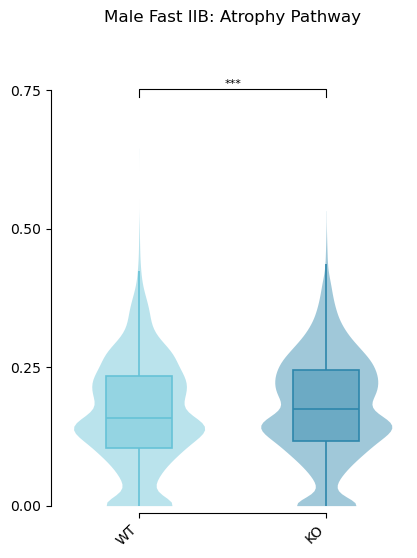

<Figure size 640x480 with 0 Axes>

In [55]:
# custom_colors = {
#     'WT': '#C4A0E7',      # '#66C2D7' Soft teal blue '#C4A0E7',# Light lavender
#     'KO': '#4B0082'   # '#2E86AB' Deeper teal blue, '#4B0082' # Indigo
# }
custom_colors = {
    'WT': '#66C2D7',      # '#66C2D7' Soft teal blue '#C4A0E7',# Light lavender
    'KO': '#2E86AB'   # '#2E86AB' Deeper teal blue, '#4B0082' # Indigo
}

fig = plot_violin_box_combo(
    data=cell_level_scores_df,
    x_var='condition',
    y_var='Atrophy Pathway (PMID: 31325479)',
    title='Male Fast IIB: Atrophy Pathway',
    x_ticks=['WT', 'KO'],
    palette=custom_colors,
    rotation=45,
    show_scatter=False,
    show_pvalue=False
)

# Display the plot
from IPython.display import display
display(fig)

# save svg 
fig.savefig('/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/score_figs/male_fast_iib_atrophy_pathway.svg', format="svg", bbox_inches="tight")

In [56]:
# plot_pathway_dotplot(
#     cell_level_scores_df,
#     score_cols=['GOBP_FATTY_ACID_BETA_OXIDATION', 'KEGG_GLYCOLYSIS_GLUCONEOGENESIS', 'KEGG_OXIDATIVE_PHOSPHORYLATION'],
#     sample_col='sample_id',
#     sample_order=['F3_WT', 'F4_WT', 'F15_WT'],
#     annotation_col='C_scANVI', 
#     target_annotation='Fast IIB',
#     ylabel="Metabolic Pathways"
# )